In [1]:
import gpxpy
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import folium
from folium.plugins import MeasureControl
from haversine import haversine
import json
import os
import colorsys
import random
import math
import googlemaps
import time
from datetime import datetime
import polyline
from dotenv import load_dotenv

def initialize_google_maps_client(api_key):
    """
    Initialize Google Maps client with API key
    """
    return googlemaps.Client(key=api_key)

def load_gpx_to_dataframe(gpx_file):
    """
    Load a GPX file into a pandas DataFrame with distance calculations
    """
    with open(gpx_file, 'r') as f:
        gpx = gpxpy.parse(f)
    
    # Extract points
    points = []
    for track in gpx.tracks:
        for segment in track.segments:
            for point in segment.points:
                points.append({
                    'latitude': point.latitude,
                    'longitude': point.longitude,
                    'elevation': point.elevation if point.elevation else 0,
                    'time': point.time
                })
    
    # Convert to DataFrame
    df = pd.DataFrame(points)
    
    # Calculate cumulative distance
    df['segment_distance'] = 0.0
    for i in range(1, len(df)):
        point1 = (df.iloc[i-1]['latitude'], df.iloc[i-1]['longitude'])
        point2 = (df.iloc[i]['latitude'], df.iloc[i]['longitude'])
        df.loc[i, 'segment_distance'] = haversine(point1, point2, unit='km')
    
    df['cumulative_distance'] = df['segment_distance'].cumsum()
    
    # Calculate elevation gain/loss
    df['elevation_change'] = 0.0
    for i in range(1, len(df)):
        df.loc[i, 'elevation_change'] = df.iloc[i]['elevation'] - df.iloc[i-1]['elevation']
    
    df['elevation_gain'] = df['elevation_change'].apply(lambda x: max(0, x))
    df['elevation_loss'] = df['elevation_change'].apply(lambda x: abs(min(0, x)))
    df['cumulative_elevation_gain'] = df['elevation_gain'].cumsum()
    
    return df

def get_distinct_colors(n):
    """
    Generate n visually distinct colors for routes
    """
    colors = []
    for i in range(n):
        # Use HSV color space to generate evenly distributed colors
        h = i / n
        s = 0.8 + random.uniform(-0.1, 0.1)  # Add slight randomness to saturation
        v = 0.9 + random.uniform(-0.1, 0.1)  # Add slight randomness to value
        r, g, b = colorsys.hsv_to_rgb(h, s, v)
        # Convert to hex
        color = "#{:02x}{:02x}{:02x}".format(int(r*255), int(g*255), int(b*255))
        colors.append(color)
    return colors

def calculate_optimal_rv_stops(route_df, target_distance=125, gmaps_client=None):
    """
    Calculate optimal RV stop locations based on target daily distance
    and check for RV accessibility using Google Maps API
    """
    total_distance = route_df['cumulative_distance'].iloc[-1]
    num_days = math.ceil(total_distance / target_distance)
    
    # Initial stops based on distance
    initial_stops = []
    for day in range(1, num_days):
        target_distance_km = day * target_distance
        # Find the closest point to the target distance
        closest_idx = (route_df['cumulative_distance'] - target_distance_km).abs().idxmin()
        initial_stops.append({
            'day': day,
            'distance_km': route_df.loc[closest_idx, 'cumulative_distance'],
            'latitude': route_df.loc[closest_idx, 'latitude'],
            'longitude': route_df.loc[closest_idx, 'longitude'],
            'elevation': route_df.loc[closest_idx, 'elevation'],
            'elevation_gain_so_far': route_df.loc[closest_idx, 'cumulative_elevation_gain'],
            'index': closest_idx
        })
    
    optimal_stops = []
    
    # If we have Google Maps API access, optimize stops for RV accessibility
    if gmaps_client:
        print("Optimizing RV stops using Google Maps API...")
        for stop in initial_stops:
            # Find nearest road accessible point
            reverse_geocode = gmaps_client.reverse_geocode((stop['latitude'], stop['longitude']))
            
            # Check if this is a valid address with road access
            if reverse_geocode and 'formatted_address' in reverse_geocode[0]:
                # Try to find better stopping points nearby (campgrounds, RV parks, etc)
                better_stop = find_better_rv_stop(gmaps_client, stop['latitude'], stop['longitude'])
                
                if better_stop:
                    # Update with better location
                    stop.update({
                        'latitude': better_stop['lat'],
                        'longitude': better_stop['lng'],
                        'place_name': better_stop['name'],
                        'place_address': better_stop['address'],
                        'place_type': better_stop['type']
                    })
                else:
                    # Use the reverse geocoded address
                    stop.update({
                        'place_name': 'Road Stop',
                        'place_address': reverse_geocode[0]['formatted_address'],
                        'place_type': 'road'
                    })
            
            optimal_stops.append(stop)
            
            # Rate limiting to avoid exceeding API quotas
            time.sleep(0.2)
    else:
        # Without Google Maps API, just use the initial stops
        optimal_stops = initial_stops
        print("No Google Maps API provided. Using basic RV stop calculations.")
        
    return optimal_stops

def find_better_rv_stop(gmaps_client, lat, lng, radius=5000):
    """
    Find a better RV stop (campground, RV park, etc.) near the given coordinates
    """
    rv_keywords = ['rv park', 'campground', 'camping', 'rest area', 'truck stop', 'gas station']
    
    for keyword in rv_keywords:
        try:
            # Search for places matching the keyword
            places_result = gmaps_client.places_nearby(
                location=(lat, lng),
                radius=radius,
                keyword=keyword
            )
            
            # If we found any places, return the first one
            if places_result and 'results' in places_result and places_result['results']:
                place = places_result['results'][0]
                
                # Get additional details about the place
                place_details = gmaps_client.place(place['place_id'], fields=['name', 'formatted_address', 'geometry', 'type'])
                
                if place_details and 'result' in place_details:
                    result = place_details['result']
                    return {
                        'name': result.get('name', 'Unnamed Location'),
                        'address': result.get('formatted_address', 'Unknown Address'),
                        'lat': result['geometry']['location']['lat'],
                        'lng': result['geometry']['location']['lng'],
                        'type': keyword
                    }
        except Exception as e:
            print(f"Error searching for {keyword}: {e}")
            
        # Rate limiting
        time.sleep(0.2)
            
    return None

def find_nearby_facilities(gmaps_client, lat, lng, radius=5000):
    """
    Find nearby facilities using Google Maps Places API
    """
    if not gmaps_client:
        # Return dummy data if no API client
        return {
            'has_gas_station': False,
            'has_grocery': False,
            'has_lodging': False,
            'has_water': False
        }
    
    facilities = {
        'has_gas_station': False,
        'has_grocery': False,
        'has_lodging': False,
        'has_water': False
    }
    
    # Check for gas stations
    try:
        gas_result = gmaps_client.places_nearby(
            location=(lat, lng),
            radius=radius,
            type='gas_station'
        )
        facilities['has_gas_station'] = bool(gas_result and 'results' in gas_result and gas_result['results'])
    except Exception as e:
        print(f"Error checking for gas stations: {e}")
    
    # Check for grocery stores
    try:
        grocery_result = gmaps_client.places_nearby(
            location=(lat, lng),
            radius=radius,
            type='grocery_or_supermarket'
        )
        facilities['has_grocery'] = bool(grocery_result and 'results' in grocery_result and grocery_result['results'])
    except Exception as e:
        print(f"Error checking for grocery stores: {e}")
    
    # Check for lodging
    try:
        lodging_result = gmaps_client.places_nearby(
            location=(lat, lng),
            radius=radius,
            type='lodging'
        )
        facilities['has_lodging'] = bool(lodging_result and 'results' in lodging_result and lodging_result['results'])
    except Exception as e:
        print(f"Error checking for lodging: {e}")
    
    # Rate limiting
    time.sleep(0.2)
    
    return facilities

def analyze_route_segments(route_df, stops, gmaps_client=None):
    """
    Analyze each day's segment for difficulty and key statistics,
    optionally using Google Maps API for terrain data
    """
    segments = []
    
    # Add starting point
    start_point = {
        'day': 0,
        'distance_km': 0,
        'latitude': route_df.iloc[0]['latitude'],
        'longitude': route_df.iloc[0]['longitude'],
        'elevation': route_df.iloc[0]['elevation'],
        'elevation_gain_so_far': 0
    }
    
    all_stops = [start_point] + stops + [{
        'day': len(stops) + 1,
        'distance_km': route_df.iloc[-1]['cumulative_distance'],
        'latitude': route_df.iloc[-1]['latitude'],
        'longitude': route_df.iloc[-1]['longitude'],
        'elevation': route_df.iloc[-1]['elevation'],
        'elevation_gain_so_far': route_df.iloc[-1]['cumulative_elevation_gain']
    }]
    
    for i in range(len(all_stops)-1):
        start = all_stops[i]
        end = all_stops[i+1]
        
        # Filter route for this segment
        start_idx = (route_df['cumulative_distance'] - start['distance_km']).abs().idxmin()
        end_idx = (route_df['cumulative_distance'] - end['distance_km']).abs().idxmin()
        
        segment_df = route_df.iloc[start_idx:end_idx+1].copy()
        
        # Calculate segment statistics
        segment_distance = end['distance_km'] - start['distance_km']
        segment_elevation_gain = end['elevation_gain_so_far'] - start['elevation_gain_so_far']
        
        # Basic difficulty calculation
        difficulty = 1.0
        difficulty += segment_elevation_gain / 500  # Add 1 difficulty point per 500m of elevation gain
        
        # Additional terrain info
        terrain_info = {}
        
        # If we have Google Maps API access, get additional data
        if gmaps_client:
            # Get route details from Google Maps
            start_coord = (start['latitude'], start['longitude'])
            end_coord = (end['latitude'], end['longitude'])
            
            try:
                # Get route details from Google Maps
                directions_result = gmaps_client.directions(
                    origin=start_coord,
                    destination=end_coord,
                    mode="walking"  # Use walking for ultra running routes
                )
                
                if directions_result and len(directions_result) > 0:
                    route = directions_result[0]
                    
                    if 'legs' in route and len(route['legs']) > 0:
                        leg = route['legs'][0]
                        
                        # Get Google's distance calculation
                        google_distance = leg['distance']['value'] / 1000  # convert meters to km
                        
                        # Add terrain information
                        terrain_info = {
                            'google_distance_km': google_distance,
                            'google_duration': leg['duration']['text'],
                            'start_address': leg['start_address'],
                            'end_address': leg['end_address']
                        }
                        
                        # Check for significant difference in distance calculation
                        if abs(google_distance - segment_distance) > segment_distance * 0.2:
                            difficulty *= google_distance / segment_distance
                        
                        # Check for warnings
                        if 'warnings' in route and route['warnings']:
                            terrain_info['warnings'] = route['warnings']
                            difficulty += len(route['warnings']) * 0.5
            except Exception as e:
                print(f"Error getting Google Maps directions: {e}")
                time.sleep(0.5)  # Pause if we hit an error
        
        # Create the segment info
        segments.append({
            'day': i+1,
            'start_point': (start['latitude'], start['longitude']),
            'end_point': (end['latitude'], end['longitude']),
            'distance_km': segment_distance,
            'elevation_gain_m': segment_elevation_gain,
            'difficulty_score': round(difficulty, 2),
            'estimated_hours': segment_distance / 8,  # Assuming 8 km/h pace
            'terrain_info': terrain_info
        })
    
    return segments

def create_integrated_map(route_data, google_maps_api_key=None):
    """
    Create an integrated interactive map with hover information and optimized RV stops
    
    Parameters:
    - route_data: Dictionary containing processed route data
    - google_maps_api_key: Optional Google Maps API key for additional features
    
    Returns:
    - Path to the generated HTML file
    """
    # Get all coordinates to center the map
    all_lats = []
    all_lons = []
    for route_name, data in route_data.items():
        df = data['df']
        all_lats.extend(df['latitude'].tolist())
        all_lons.extend(df['longitude'].tolist())
    
    # Create a map centered on all routes
    center_lat = sum(all_lats) / len(all_lats)
    center_lon = sum(all_lons) / len(all_lons)
    
    integrated_map = folium.Map(location=[center_lat, center_lon], zoom_start=8)
    
    # Add measurement tools
    integrated_map.add_child(MeasureControl())
    
    # Generate distinct colors for each route
    colors = get_distinct_colors(len(route_data))
    
    # Create the JavaScript for interactive hover functionality
    hover_js = """
    <script>
    // Store route data for hover lookups
    var routeDataPoints = {};
    var currentRouteIndex = -1;
    var mapObject = null;
    
    // Create hover info box
    var infoBox = document.createElement('div');
    infoBox.id = 'hover-info-box';
    infoBox.style.cssText = 'position: fixed; bottom: 10px; left: 10px; background: white; padding: 10px; border-radius: 5px; border: 1px solid #ccc; z-index: 9999; display: none; min-width: 200px; box-shadow: 0 1px 5px rgba(0,0,0,0.4);';
    infoBox.innerHTML = `
      <h4 id="route-name" style="margin: 0 0 5px 0;"></h4>
      <div id="distance-info"></div>
      <div id="elevation-info"></div>
      <div id="elev-gain-info"></div>
    `;
    document.body.appendChild(infoBox);
    
    // Find Leaflet map object
    function getMapObject() {
        if (mapObject) return mapObject;
        
        for (var key in window) {
            if (window[key] && 
                typeof window[key] === 'object' && 
                window[key]._leaflet_id && 
                window[key].boxZoom) {
                mapObject = window[key];
                return mapObject;
            }
        }
        return null;
    }
    
    // Show information for the closest point on a route
    function showPointInfo(map, latlng) {
        if (currentRouteIndex === -1) return;
        
        var routeNames = Object.keys(routeDataPoints);
        if (currentRouteIndex >= routeNames.length) return;
        
        var routeName = routeNames[currentRouteIndex];
        var points = routeDataPoints[routeName];
        
        // Find closest point
        var minDist = Infinity;
        var closestPoint = null;
        
        for (var i = 0; i < points.length; i++) {
            var point = points[i];
            var pointLatLng = L.latLng(point.lat, point.lng);
            var dist = map.distance(latlng, pointLatLng);
            
            if (dist < minDist) {
                minDist = dist;
                closestPoint = point;
            }
        }
        
        // Only show info if point is within 100 meters
        if (closestPoint && minDist < 100) {
            document.getElementById('route-name').textContent = routeName;
            document.getElementById('distance-info').textContent = 'Distance from start: ' + closestPoint.distance.toFixed(2) + ' km';
            document.getElementById('elevation-info').textContent = 'Current elevation: ' + closestPoint.elevation.toFixed(0) + ' m';
            document.getElementById('elev-gain-info').textContent = 'Cumulative gain: ' + closestPoint.elevGain.toFixed(0) + ' m';
            
            infoBox.style.display = 'block';
        } else {
            infoBox.style.display = 'none';
        }
    }
    
    // Initialize hover functionality when DOM is loaded
    document.addEventListener('DOMContentLoaded', function() {
        // Wait for map to initialize
        setTimeout(function() {
            var map = getMapObject();
            if (!map) {
                console.error("Could not find map object");
                return;
            }
            
            console.log("Map initialized, hover functionality ready");
            console.log("Available routes:", Object.keys(routeDataPoints));
            
            // Set up mousemove handler
            map.on('mousemove', function(e) {
                if (currentRouteIndex !== -1) {
                    showPointInfo(map, e.latlng);
                }
            });
            
        }, 1000);
    });
    </script>
    """
    
    # Add the hover JavaScript to the map
    integrated_map.get_root().html.add_child(folium.Element(hover_js))
    
    # Process and add each route to the map
    for i, (route_name, data) in enumerate(route_data.items()):
        route_df = data['df']
        rv_stops = data['rv_stops']
        color = colors[i]
        
        # Prepare points data for hover functionality
        js_points = []
        for _, row in route_df.iterrows():
            js_points.append({
                'lat': row['latitude'],
                'lng': row['longitude'],
                'elevation': row['elevation'],
                'distance': row['cumulative_distance'],
                'elevGain': row['cumulative_elevation_gain']
            })
        
        # Add route data to JavaScript
        js_points_str = json.dumps(js_points)
        integrated_map.get_root().script.add_child(folium.Element(
            f'routeDataPoints["{route_name}"] = {js_points_str};'
        ))
        
        # Create route line with mouseover/mouseout events
        points = [(row['latitude'], row['longitude']) for _, row in route_df.iterrows()]
        
        # Add route path
        route_line = folium.PolyLine(
            points,
            color=color,
            weight=4,
            opacity=0.8,
            tooltip=f"{route_name} - {data['total_distance']:.1f} km"
        ).add_to(integrated_map)
        
        # Add event handlers for this route
        route_event_js = f"""
        // Route event handlers for {route_name}
        (function() {{
            var route = document.querySelector('.leaflet-interactive:nth-child({i+1})');
            if (route) {{
                route.addEventListener('mouseover', function() {{ 
                    currentRouteIndex = {i}; 
                    console.log("Activated route: {route_name}");
                }});
                
                route.addEventListener('mouseout', function() {{ 
                    currentRouteIndex = -1; 
                    document.getElementById('hover-info-box').style.display = 'none';
                }});
            }}
        }})();
        """
        
        integrated_map.get_root().script.add_child(folium.Element(route_event_js))
        
        # Add start marker
        folium.Marker(
            [route_df.iloc[0]['latitude'], route_df.iloc[0]['longitude']],
            popup=f"Start: {route_name}",
            icon=folium.Icon(color='green', icon='play', prefix='fa')
        ).add_to(integrated_map)
        
        # Add end marker
        folium.Marker(
            [route_df.iloc[-1]['latitude'], route_df.iloc[-1]['longitude']],
            popup=f"End: {route_name}",
            icon=folium.Icon(color='red', icon='stop', prefix='fa')
        ).add_to(integrated_map)
        
        # Add RV stop markers with detailed popups
        for stop in rv_stops:
            # Get facility information if available
            if google_maps_api_key:
                gmaps = initialize_google_maps_client(google_maps_api_key)
                facilities = find_nearby_facilities(gmaps, stop['latitude'], stop['longitude'])
            else:
                facilities = {
                    'has_gas_station': False,
                    'has_grocery': False,
                    'has_lodging': False,
                    'has_water': True
                }
            
            # Create popup content
            if 'place_name' in stop:
                popup_html = f"""
                <div style="min-width: 200px;">
                    <h4>Day {stop['day']} RV Stop</h4>
                    <strong>{stop['place_name']}</strong><br>
                    {stop.get('place_address', 'No address available')}<br>
                    <hr>
                    <strong>Route Stats:</strong><br>
                    Distance from start: {stop['distance_km']:.2f} km<br>
                    Elevation: {stop['elevation']:.0f} m<br>
                    Elevation gain: {stop['elevation_gain_so_far']:.0f} m<br>
                    <hr>
                    <strong>Nearby Facilities:</strong><br>
                    <ul style="margin: 0; padding-left: 20px;">
                        <li>Gas station: {'Yes' if facilities['has_gas_station'] else 'No'}</li>
                        <li>Grocery: {'Yes' if facilities['has_grocery'] else 'No'}</li>
                        <li>Lodging: {'Yes' if facilities['has_lodging'] else 'No'}</li>
                        <li>Water: {'Yes' if facilities['has_water'] else 'No'}</li>
                    </ul>
                </div>
                """
            else:
                popup_html = f"""
                <div style="min-width: 200px;">
                    <h4>Day {stop['day']} RV Stop</h4>
                    <hr>
                    <strong>Route Stats:</strong><br>
                    Distance from start: {stop['distance_km']:.2f} km<br>
                    Elevation: {stop['elevation']:.0f} m<br>
                    Elevation gain: {stop['elevation_gain_so_far']:.0f} m<br>
                    <hr>
                    <strong>Nearby Facilities:</strong><br>
                    <ul style="margin: 0; padding-left: 20px;">
                        <li>Gas station: {'Yes' if facilities['has_gas_station'] else 'No'}</li>
                        <li>Grocery: {'Yes' if facilities['has_grocery'] else 'No'}</li>
                        <li>Lodging: {'Yes' if facilities['has_lodging'] else 'No'}</li>
                        <li>Water: {'Yes' if facilities['has_water'] else 'No'}</li>
                    </ul>
                </div>
                """
            
            # Create marker
            icon_type = 'home' if 'place_type' in stop and stop['place_type'] in ['rv park', 'campground', 'camping'] else 'flag'
            folium.Marker(
                [stop['latitude'], stop['longitude']],
                popup=folium.Popup(popup_html, max_width=300),
                icon=folium.Icon(color=color, icon=icon_type, prefix='fa')
            ).add_to(integrated_map)
    
    # Add a legend for the routes
    legend_html = """
    <div style="position: fixed; bottom: 50px; right: 10px; background: white; padding: 10px; border: 1px solid grey; z-index:1000; border-radius: 5px;">
    <h4>Routes</h4>
    """
    
    for i, route_name in enumerate(route_data.keys()):
        color = colors[i]
        legend_html += f'<div><span style="background-color:{color}; width:15px; height:15px; display:inline-block;"></span> {route_name}</div>'
    
    legend_html += "</div>"
    integrated_map.get_root().html.add_child(folium.Element(legend_html))
    
    # Add a summary table
    summary_html = """
    <div style="position: fixed; top: 10px; right: 10px; background: white; padding: 10px; border: 1px solid grey; z-index:1000; border-radius: 5px;">
    <h4>Route Summary</h4>
    <table style="width:100%">
      <tr>
        <th>Route</th>
        <th>Distance (km)</th>
        <th>Elevation Gain (m)</th>
        <th>Est. Days</th>
      </tr>
    """
    
    for i, (route_name, data) in enumerate(route_data.items()):
        color = colors[i]
        days = len(data['rv_stops']) + 1
        summary_html += f"""
        <tr>
          <td><span style="background-color:{color}; width:12px; height:12px; display:inline-block;"></span> {route_name}</td>
          <td>{data['total_distance']:.1f}</td>
          <td>{data['total_elevation_gain']:.0f}</td>
          <td>{days}</td>
        </tr>
        """
    
    summary_html += """
    </table>
    </div>
    """
    integrated_map.get_root().html.add_child(folium.Element(summary_html))
    
    # Save the map
    html_filename = "../output/integrated_route_map.html"
    integrated_map.save(html_filename)
    print(f"Integrated map saved to: {html_filename}")
    
    return html_filename

def process_gpx_files(gpx_files, google_maps_api_key=None, target_daily_distance=125):
    """
    Process multiple GPX files and create an integrated visualization
    
    Parameters:
    - gpx_files: List of GPX file paths
    - google_maps_api_key: Optional Google Maps API key
    - target_daily_distance: Target distance per day in km
    
    Returns:
    - Dictionary with processed route data
    - Path to the generated HTML file
    """
    # Initialize Google Maps client if API key is provided
    gmaps_client = None
    if google_maps_api_key:
        try:
            gmaps_client = initialize_google_maps_client(google_maps_api_key)
            print("Google Maps API initialized successfully.")
        except Exception as e:
            print(f"Error initializing Google Maps API: {e}")
            print("Continuing without Google Maps integration.")
    
    # Process each GPX file
    route_data = {}
    for gpx_file in gpx_files:
        route_name = os.path.basename(gpx_file).replace('.gpx', '')
        print(f"\nProcessing route: {route_name}")
        
        # Load GPX data
        route_df = load_gpx_to_dataframe(gpx_file)
        total_distance = route_df['cumulative_distance'].iloc[-1]
        total_elevation_gain = route_df['cumulative_elevation_gain'].iloc[-1]
        
        print(f"  Total distance: {total_distance:.2f} km")
        print(f"  Total elevation gain: {total_elevation_gain:.0f} m")
        
        # Calculate optimal RV stops
        rv_stops = calculate_optimal_rv_stops(route_df, target_daily_distance, gmaps_client)
        
        # Analyze route segments
        segments = analyze_route_segments(route_df, rv_stops, gmaps_client)
        
        # Store route data
        route_data[route_name] = {
            'df': route_df,
            'rv_stops': rv_stops,
            'segments': segments,
            'total_distance': total_distance,
            'total_elevation_gain': total_elevation_gain
        }
        
        # Print RV stop information
        print(f"  Optimal RV stops:")
        for stop in rv_stops:
            if 'place_name' in stop:
                print(f"    Day {stop['day']}: {stop['place_name']} - {stop['distance_km']:.2f} km")
            else:
                print(f"    Day {stop['day']}: {stop['distance_km']:.2f} km")
    
    # Create the integrated map
    html_file = create_integrated_map(route_data, google_maps_api_key)
    
    return route_data, html_file

def main(gpx_files, google_maps_api_key=None, target_daily_distance=125):
    """
    Main function to process GPX files and create integrated visualization
    
    Parameters:
    - gpx_files: List of GPX file paths
    - google_maps_api_key: Optional Google Maps API key
    - target_daily_distance: Target distance per day in km
    
    Returns:
    - Path to the generated HTML file
    """
    #google_maps_api_key = os.getenv("MAPS_API_KEY")
    route_data, html_file = process_gpx_files(gpx_files, google_maps_api_key, target_daily_distance)
    
    print(f"\nAnalysis complete!")
    print(f"Integrated map with Google Maps data and hover functionality saved to: {html_file}")
    
    return html_file


In [2]:
from dotenv import load_dotenv

load_dotenv()
#maps_api_key = os.getenv("MAPS_API_KEY")

In [3]:
gpx_files = ['../gpx/TSP LALV Jonty Solo option a.gpx', '../gpx/TSP LALV Jonty Solo option b.gpx', '../gpx/OG_TSP.gpx']

In [5]:
route_analysis = main(gpx_files, target_daily_distance=125)

Google Maps API initialized successfully.

Processing route: TSP LALV Jonty Solo option a
  Total distance: 476.30 km
  Total elevation gain: 4227 m
Optimizing RV stops using Google Maps API...
  Optimal RV stops:
    Day 1: Bonita Ranch Campground - 124.99 km
    Day 2: OSR Campground - 249.99 km
    Day 3: Valley Wells Rest Area - Northbound - 375.03 km

Processing route: TSP LALV Jonty Solo option b
  Total distance: 474.78 km
  Total elevation gain: 4456 m
Optimizing RV stops using Google Maps API...
  Optimal RV stops:
    Day 1: Road Stop - 124.97 km
    Day 2: OSR Campground - 250.00 km
    Day 3: Valley Wells Rest Area - Northbound - 375.00 km

Processing route: OG_TSP
  Total distance: 559.89 km
  Total elevation gain: 4595 m
Optimizing RV stops using Google Maps API...
  Optimal RV stops:
    Day 1: Loma Linda RV Trailer Park - 125.10 km
    Day 2: Elm Grove Trailer Park - 249.92 km
    Day 3: Road Stop - 375.73 km
    Day 4: Road Stop - 502.63 km


/var/folders/ss/kjxldrfs36qgygzmg25sqy100000gn/T/ipykernel_26236/3150450674.py:614: UserWarning: color argument of Icon should be one of: {'lightblue', 'cadetblue', 'beige', 'lightgray', 'black', 'lightred', 'darkblue', 'blue', 'red', 'orange', 'white', 'pink', 'green', 'lightgreen', 'darkgreen', 'darkpurple', 'darkred', 'gray', 'purple'}.
  icon=folium.Icon(color=color, icon=icon_type, prefix='fa')


Integrated map saved to: ../output/integrated_route_map.html

Analysis complete!
Integrated map with Google Maps data and hover functionality saved to: ../output/integrated_route_map.html


In [ ]:
from gpx_analyser import analyze_gpx_file

analysis = analyze_gpx_file('../gpx/OG_TSP.gpx')

In [ ]:
tmpgpx = load_gpx_to_dataframe(gpx_file='../gpx/HS_TSP_Solo.gpx')

tmpgpx.tail()

In [8]:
from route_compare import GPXRouteAnalyzer

In [9]:
def analyze_la_to_vegas_routes():
    """
    Analyze GPX routes from Los Angeles to Las Vegas
    comparing difficulty, elevation, gradient, and terrain.
    """
    # Initialize the analyzer with 125km segment length
    analyzer = GPXRouteAnalyzer(
        segment_length=125,
        google_maps_api_key=""
    )
    
    # Load your GPX files
    # Update these paths to your actual GPX file locations
    gpx_files = [
        {"path": "../gpx/TSP LALV Jonty Solo option a.gpx", "name": "Route A"},
        {"path": "../gpx/TSP LALV Jonty Solo option b.gpx", "name": "Route B"},
        {"path": "../gpx/OG_TSP.gpx", "name": "OG",}
    ]
    
    # Load each file
    for gpx_file in gpx_files:
        if os.path.exists(gpx_file["path"]):
            print(f"Loading {gpx_file['name']}...")
            analyzer.load_gpx_file(gpx_file["path"], gpx_file["name"])
        else:
            print(f"Warning: {gpx_file['path']} not found. Skipping.")
    
    # Generate overall comparison
    print("\n=== ROUTE COMPARISON ===")
    analyzer.compare_routes_table()
    
    # Generate detailed 125km segment reports for each route
    for gpx_file in gpx_files:
        route_name = gpx_file["name"]
        print(f"\n=== SEGMENT ANALYSIS: {route_name} ===")
        analyzer.print_segment_summaries(route_name)
    
    # Create visualizations
    print("\nGenerating visualizations...")
    
    # 1. Elevation profiles
    analyzer.plot_elevation_profiles(figsize=(14, 7), highlight_segments=True)
    
    # 2. Gradient profiles
    analyzer.plot_gradient_profiles(figsize=(14, 7))
    
    # 3. Terrain distribution (if Google Maps API key provided)
    #if maps_api_key and maps_api_key != "YOUR_API_KEY":
    #    analyzer.plot_terrain_distribution(figsize=(14, 7))
    
    # 4. Difficulty radar chart
    analyzer.plot_difficulty_radar(figsize=(10, 10))
    
    # 5. Interactive map colored by gradient
    route_map = analyzer.create_interactive_map(color_by='gradient')
    if route_map:
        map_file = "la_vegas_routes_map.html"
        route_map.save(map_file)
        print(f"Interactive map saved to {map_file}")
    
    # Export comprehensive HTML report
    report_file = "la_vegas_route_analysis.html"
    analyzer.export_to_html(report_file)
    print(f"Detailed analysis report saved to {report_file}")

Loading Route A...
Loaded 6453 points from ../gpx/TSP LALV Jonty Solo option a.gpx
Loading Route B...
Loaded 6298 points from ../gpx/TSP LALV Jonty Solo option b.gpx
Loading OG...
Loaded 2716 points from ../gpx/OG_TSP.gpx

=== ROUTE COMPARISON ===

ROUTE COMPARISON TABLE
         Difficulty Rank  Distance (km)  Elevation Gain (m)  \
Route B                1          474.8              4119.7   
OG                     2          559.9              3946.6   
Route A                3          476.3              3905.5   

         Elevation Loss (m)  Max Elevation (m)  Avg Gradient (%)  \
Route B              3461.1             1448.3               0.3   
OG                   3302.6             1673.4               0.3   
Route A              3248.4             1448.3               0.3   

         Max Gradient (%)  Steep Sections  Difficulty Score  
Route B              45.0             102              79.5  
OG                   24.4             154              79.3  
Route A         

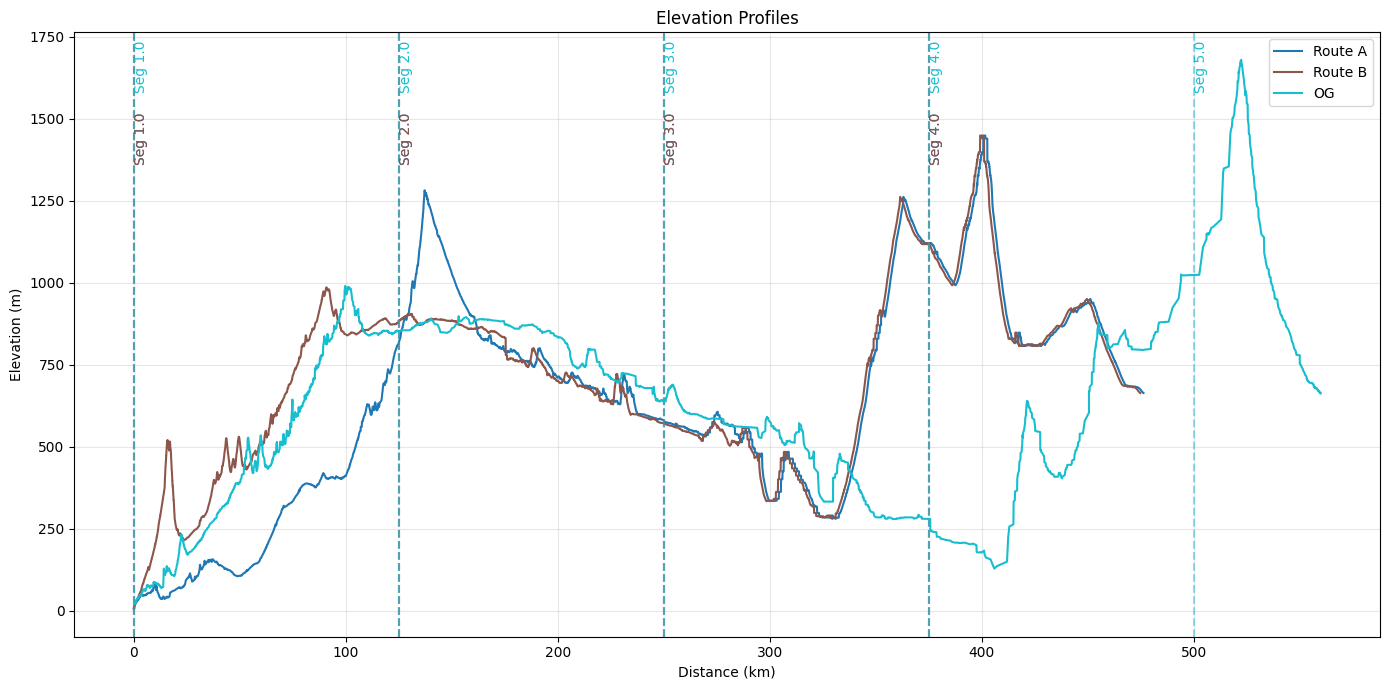

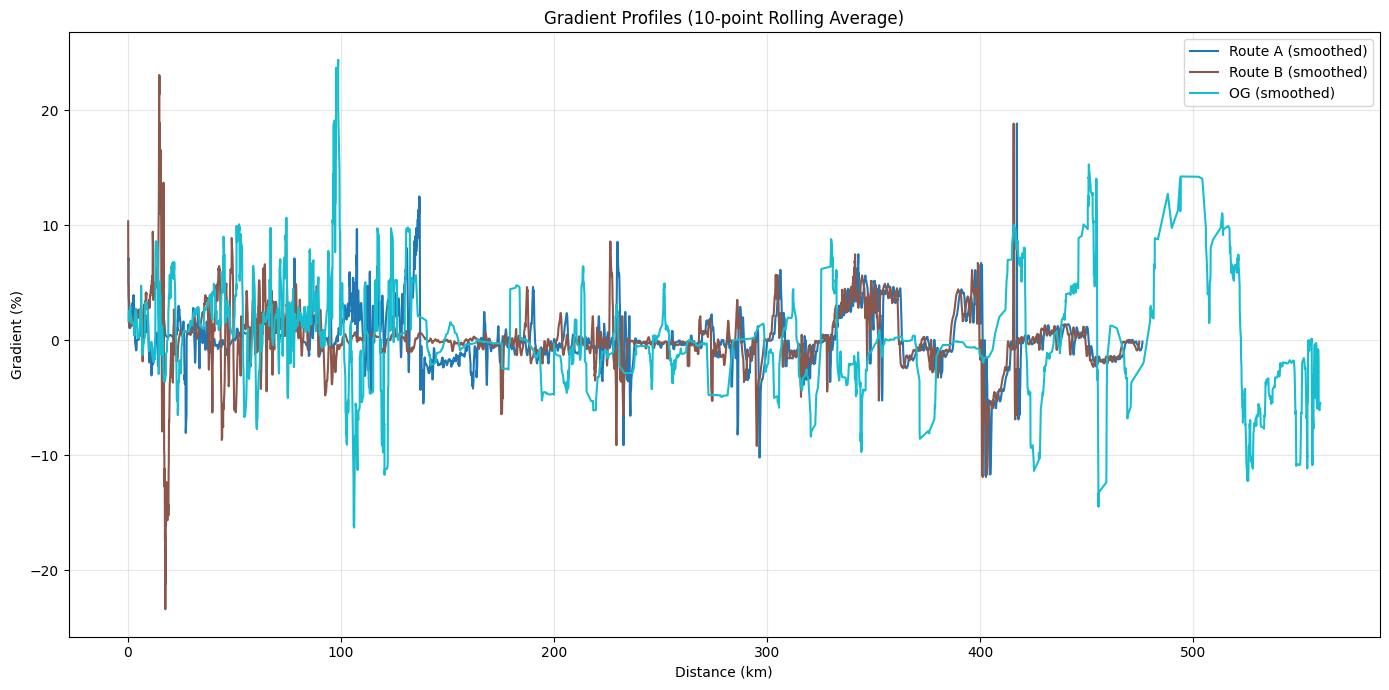

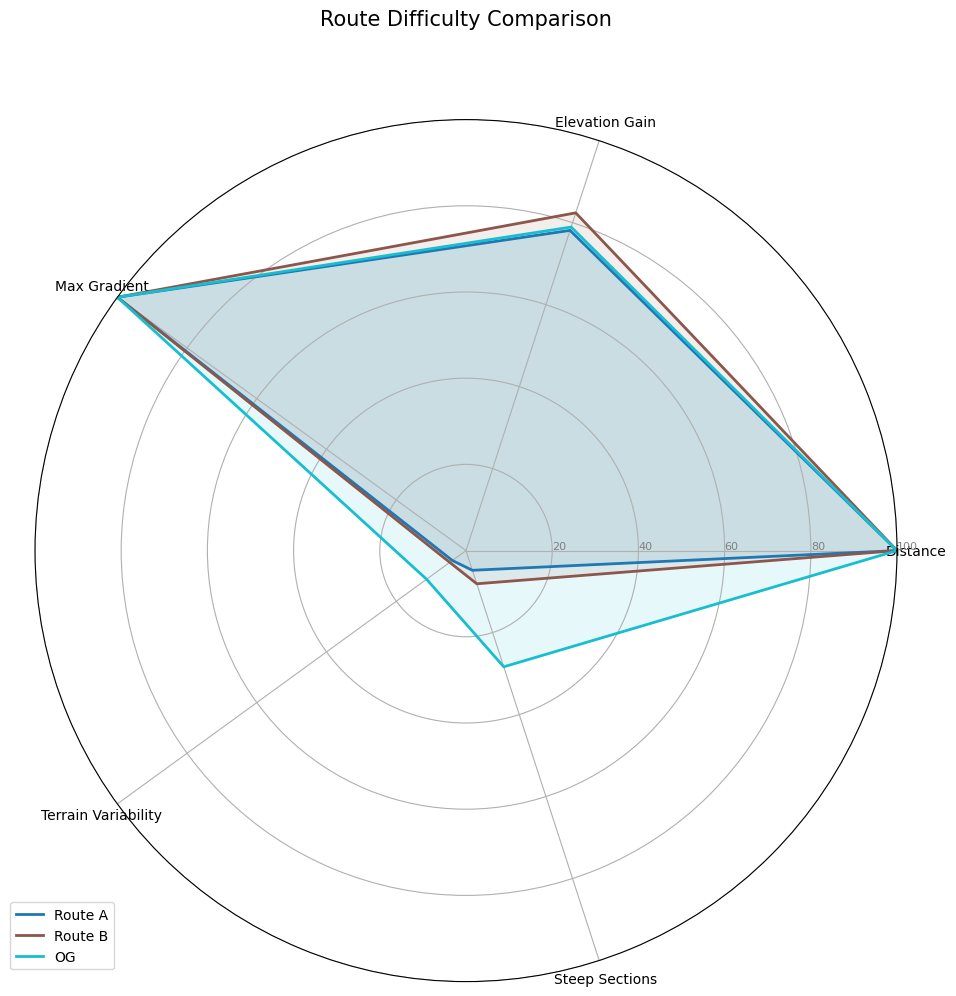

Interactive map saved to la_vegas_routes_map.html
Report exported to la_vegas_route_analysis.html
Detailed analysis report saved to la_vegas_route_analysis.html


In [10]:
analyze_la_to_vegas_routes()

### Terrain analysis

In [16]:
import math
import time
import requests
import gpxpy
from tqdm import tqdm  # For the progress bar

def haversine_distance(lat1, lon1, lat2, lon2):
    """Calculate the distance between two points (in meters) using the haversine formula."""
    R = 6371000  # Earth radius in meters
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlambda = math.radians(lon2 - lon1)
    a = math.sin(dphi/2)**2 + math.cos(phi1)*math.cos(phi2)*math.sin(dlambda/2)**2
    return 2 * R * math.atan2(math.sqrt(a), math.sqrt(1-a))

def query_surface(lat, lon, radius=50):
    """Query Overpass API for ways with a 'surface' tag near the given lat/lon."""
    query = f"""
    [out:json][timeout:25];
    (
      way(around:{radius},{lat},{lon})["surface"];
    );
    out tags;
    """
    url = "http://overpass-api.de/api/interpreter"
    try:
        response = requests.get(url, params={'data': query})
        if response.status_code == 200:
            return response.json()
        else:
            print(f"Overpass API error: {response.status_code}")
    except Exception as e:
        print("Error querying Overpass:", e)
    return None

def sample_gpx_points(file_path, sample_distance=5000):
    """
    Sample points along a GPX route every `sample_distance` (in meters).
    Returns a list of (latitude, longitude) tuples.
    """
    with open(file_path, 'r') as f:
        gpx = gpxpy.parse(f)
    
    # Collect all points from all tracks and segments.
    points = []
    for track in gpx.tracks:
        for seg in track.segments:
            points.extend(seg.points)
    if not points:
        return []
    
    sampled_points = []
    # Start with the first point.
    sampled_points.append((points[0].latitude, points[0].longitude))
    cumulative_distance = 0
    last_point = points[0]
    
    for point in points[1:]:
        d = haversine_distance(last_point.latitude, last_point.longitude, point.latitude, point.longitude)
        cumulative_distance += d
        if cumulative_distance >= sample_distance:
            sampled_points.append((point.latitude, point.longitude))
            cumulative_distance = 0
            last_point = point
            
    return sampled_points

def process_gpx_file(file_path, sample_distance=5000, segment_length=125000):
    """
    Process a single GPX file by:
      1. Sampling points along the route (every sample_distance meters).
      2. Querying the Overpass API for the surface type for each segment between sample points.
      3. Aggregating distances by surface type overall and by 125km segments.
    
    Returns:
      - overall: dict mapping surface type to total distance (meters).
      - segmented: list of tuples (segment_index, {surface: distance, ...})
        for each 125km segment (or the last partial segment).
    """
    sampled_points = sample_gpx_points(file_path, sample_distance)
    if len(sampled_points) < 2:
        print("Not enough sampled points found in the GPX file.")
        return {}, []
    
    overall = {}         # Overall distance per surface type.
    segmented = []       # List of tuples (segment_index, {surface: distance}).
    current_seg = {}     # Current 125km segment distribution.
    current_seg_distance = 0.0  # Distance accumulated in current segment.
    segment_index = 1

    # Use tqdm progress bar over the segments being processed.
    for i in tqdm(range(len(sampled_points) - 1), desc="Processing GPX segments"):
        lat1, lon1 = sampled_points[i]
        lat2, lon2 = sampled_points[i+1]
        dist = haversine_distance(lat1, lon1, lat2, lon2)
        
        # Query Overpass API at the midpoint between the two sample points.
        mid_lat = (lat1 + lat2) / 2
        mid_lon = (lon1 + lon2) / 2
        result = query_surface(mid_lat, mid_lon, radius=50)
        surface_type = None
        if result and "elements" in result and result["elements"]:
            # Use the first found surface value.
            for elem in result["elements"]:
                if "tags" in elem and "surface" in elem["tags"]:
                    surface_type = elem["tags"]["surface"]
                    break
        if not surface_type:
            surface_type = "unknown"
        
        # Update overall distance tally.
        overall[surface_type] = overall.get(surface_type, 0) + dist

        # Distribute the segment distance into 125km buckets.
        remaining_distance = dist
        while remaining_distance > 0:
            capacity = segment_length - current_seg_distance
            if remaining_distance >= capacity:
                # Fill the current segment.
                current_seg[surface_type] = current_seg.get(surface_type, 0) + capacity
                remaining_distance -= capacity
                current_seg_distance = segment_length
                # Save the filled segment.
                segmented.append((segment_index, current_seg))
                segment_index += 1
                # Reset for the next segment.
                current_seg = {}
                current_seg_distance = 0
            else:
                # Add remaining distance to the current segment.
                current_seg[surface_type] = current_seg.get(surface_type, 0) + remaining_distance
                current_seg_distance += remaining_distance
                remaining_distance = 0
        
        # Pause briefly to avoid overloading the Overpass API.
        time.sleep(0.5)
    
    # Save any partial segment.
    if current_seg:
        segmented.append((segment_index, current_seg))
    
    return overall, segmented

def process_multiple_gpx_files(file_list, sample_distance=5000, segment_length=125000):
    """
    Process multiple GPX files to aggregate surface type distances overall and by 125km segments.
    
    Returns a dictionary mapping file name to a dict with keys:
      - "overall": overall distance per surface type.
      - "segmented": list of 125km segment distributions.
    """
    results = {}
    for file_path in file_list:
        print(f"Processing {file_path}...")
        overall, segmented = process_gpx_file(file_path, sample_distance, segment_length)
        results[file_path] = {
            "overall": overall,
            "segmented": segmented
        }
    return results


In [31]:
overall, segmented = process_gpx_file('../gpx/OG_TSP.gpx', 10000, 125000)

Processing GPX segments:  98%|█████████▊| 226/230 [05:36<00:04,  1.02s/it]

Overpass API error: 504


Processing GPX segments: 100%|██████████| 230/230 [05:54<00:00,  1.54s/it]


In [32]:
#results = {}
results['OG'] = {
            "overall": overall,
            "segmented": segmented
        }

In [33]:
# Process the files
#overall, segmented = process_gpx_file('../gpx/TSP LALV Jonty Solo option a.gpx', 5000, 125000)
#results = process_multiple_gpx_files(gpx_files)

# Now you can print or further process the aggregated proportions.
for file, data in results.items():
    overall = data["overall"]
    total_distance = sum(overall.values())
    print(f"\nFile: {file}")
    print("Overall Surface Distribution:")
    for surface, d in overall.items():
        proportion = (d / total_distance) * 100 if total_distance > 0 else 0
        print(f"  {surface}: {d:.0f} m ({proportion:.1f}%)")
    
    print("\n125 km Segment Surface Distributions:")
    for seg_index, seg_data in data["segmented"]:
        seg_total = sum(seg_data.values())
        print(f"  Segment {seg_index} (total {seg_total:.0f} m):")
        for surface, d in seg_data.items():
            seg_prop = (d / seg_total) * 100 if seg_total > 0 else 0
            print(f"    {surface}: {d:.0f} m ({seg_prop:.1f}%)")


File: route_a
Overall Surface Distribution:
  asphalt: 183072 m (39.7%)
  paved: 13757 m (3.0%)
  unknown: 164159 m (35.6%)
  concrete: 6059 m (1.3%)
  unpaved: 8124 m (1.8%)
  dirt: 26883 m (5.8%)
  gravel: 7461 m (1.6%)
  mud: 1409 m (0.3%)
  sand: 4055 m (0.9%)
  compacted: 45963 m (10.0%)

125 km Segment Surface Distributions:
  Segment 1 (total 125000 m):
    asphalt: 71331 m (57.1%)
    paved: 9911 m (7.9%)
    unknown: 36240 m (29.0%)
    concrete: 6059 m (4.8%)
    unpaved: 912 m (0.7%)
    dirt: 547 m (0.4%)
  Segment 2 (total 125000 m):
    dirt: 4293 m (3.4%)
    unknown: 54004 m (43.2%)
    paved: 2456 m (2.0%)
    asphalt: 63004 m (50.4%)
    unpaved: 1244 m (1.0%)
  Segment 3 (total 125000 m):
    asphalt: 17963 m (14.4%)
    unknown: 56758 m (45.4%)
    unpaved: 5968 m (4.8%)
    gravel: 1111 m (0.9%)
    mud: 1409 m (1.1%)
    sand: 4055 m (3.2%)
    dirt: 17200 m (13.8%)
    compacted: 20536 m (16.4%)
  Segment 4 (total 85944 m):
    unknown: 17157 m (20.0%)
    compa